In [1]:
# Input Image
# SET PYTHONPATH to the parent directory 
import sys
import os
import matplotlib.pyplot as plt
if os.path.abspath("..") not in sys.path:
    sys.path.append(os.path.abspath(".."))


# Set default to double 
FILTER_SIZE = 15 
MAX_ORDER = 4 # R 
sys.path

plt.rcParams['text.usetex'] = True

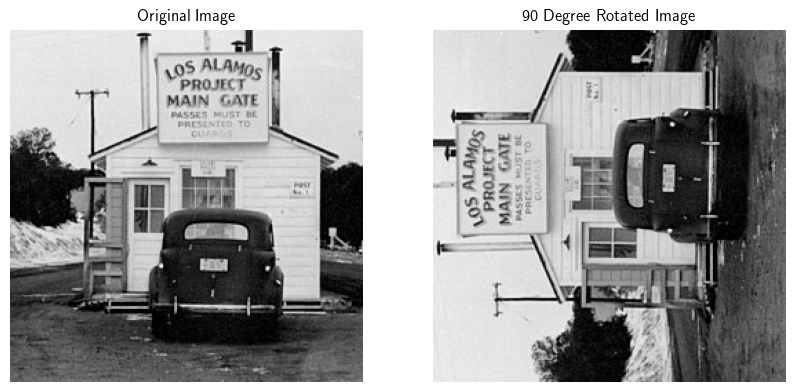

In [2]:

# Get testing image and its 90 degree rotation
import torch 
from torchvision import transforms
from hippy2d.utils import get_testing_img, get_default_complex
# Set default to double precision
torch.set_default_dtype(torch.float64)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Simulate RGB channels
test_img = get_testing_img(rgb=False)
test_img = transforms.ToTensor()(test_img).to(dtype=torch.float64)
rotated_img = torch.rot90(test_img, 1, [1, 2])
# 
test_rgb_img = get_testing_img(rgb=True)
test_rgb_img = transforms.ToTensor()(test_rgb_img).to(dtype=torch.float64)
rotated_rgb_img = torch.rot90(test_img, 1, [1, 2])
# Plot the images
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(test_img.permute(1, 2, 0).numpy(), cmap='gray')
plt.title("Original Image")
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(rotated_img.permute(1, 2, 0).numpy(), cmap='gray')
plt.title("90 Degree Rotated Image",)
plt.axis('off')
plt.show()


In [3]:
# Generate moments 

import numpy as np
from einops import repeat, rearrange
from hippy2d.complex_invariants_2d import get_complex_monomial

# Skip symmetric moments and calculate exponents of non-symmetric moments
symmetric_polynomials = []
non_symmetric_polynomials = []
non_symmetric_exponents = []
for p in range(0, MAX_ORDER + 1):
    for q in range(0, min(MAX_ORDER + 1-p, p + 1)):
        if p == q:
            symmetric_polynomials.append((p, q))
        else:
            non_symmetric_polynomials.append((p, q))
            non_symmetric_exponents.append(p - q)
# numpy arrays
non_symmetric_exponents = np.array(non_symmetric_exponents)
coef_a = repeat(non_symmetric_exponents, 'n -> m n', m=len(non_symmetric_exponents))
coef_b = repeat(non_symmetric_exponents, 'n -> n m', m=len(non_symmetric_exponents))
coef_c = coef_b 
coef_b = -coef_b
coef = np.gcd(coef_a, coef_b)
filters = [] 
negative_filters = []
# First symmetric
for (p, q) in symmetric_polynomials:
    filters.append(get_complex_monomial(FILTER_SIZE,
                                            p, q, 
                                            dtype=torch.get_default_dtype()))
# Non-symmetric
for (p, q) in non_symmetric_polynomials:
    filters.append(get_complex_monomial(FILTER_SIZE,
                                            p, q, dtype=torch.get_default_dtype()))
    negative_filters.append(get_complex_monomial(FILTER_SIZE,
                                            q, p, dtype=torch.get_default_dtype()))
    print(q-p)
# Stack filters
filters = torch.stack(filters, dim=0)[:, None]
negative_filters = torch.stack(negative_filters, dim=0)[:, None]


-1
-2
-1
-3
-2
-4


In [4]:
coef = np.gcd(coef_a, coef_b)
coef_c = coef_c // np.gcd(coef_a, coef_c)
coef_a = coef_a // coef
coef_b = coef_b // coef
coef_a, coef_b, coef_c

(array([[1, 2, 1, 3, 2, 4],
        [1, 1, 1, 3, 1, 2],
        [1, 2, 1, 3, 2, 4],
        [1, 2, 1, 1, 2, 4],
        [1, 1, 1, 3, 1, 2],
        [1, 1, 1, 3, 1, 1]]),
 array([[-1, -1, -1, -1, -1, -1],
        [-2, -1, -2, -2, -1, -1],
        [-1, -1, -1, -1, -1, -1],
        [-3, -3, -3, -1, -3, -3],
        [-2, -1, -2, -2, -1, -1],
        [-4, -2, -4, -4, -2, -1]]),
 array([[1, 1, 1, 1, 1, 1],
        [2, 1, 2, 2, 1, 1],
        [1, 1, 1, 1, 1, 1],
        [3, 3, 3, 1, 3, 3],
        [2, 1, 2, 2, 1, 1],
        [4, 2, 4, 4, 2, 1]]))

In [5]:
#gcds = np.gcd(coef_a, coef_b)
#coef_a = coef_a // gcds
#coef_b = coef_b // gcds
#non_symmetric_exponents


In [6]:
from torch.nn.functional import conv2d

x = repeat(test_img, 'c h w -> b c h w', b=1).to(dtype=get_default_complex())
rot_x = repeat(rotated_img, 'c h w -> b c h w', b=1).to(dtype=get_default_complex())


c_channels = conv2d(x, filters, padding='valid')
rot_channels = conv2d(rot_x, filters, padding='valid')

c_symmetric_moments = torch.view_as_real(c_channels[:, :len(symmetric_polynomials)])
rot_symmetric_moments = torch.view_as_real(rot_channels[:, :len(symmetric_polynomials)])

In [7]:
c_symmetric_moments = c_channels[:, :len(symmetric_polynomials)]
rot_symmetric_moments = rot_channels[:, :len(symmetric_polynomials)]

#

torch.testing.assert_close(c_symmetric_moments, torch.rot90(rot_symmetric_moments, k=-1, dims=[-2, -1]))

c_nonsymmetric_moments = c_channels[:, len(symmetric_polynomials):]
rot_nonsymmetric_moments = rot_channels[:, len(symmetric_polynomials):]

neg_c_nonsymmetric_moments = conv2d(x, negative_filters, padding='valid')
neg_rot_nonsymmetric_moments = conv2d(rot_x, negative_filters, padding='valid')

In [8]:
a = c_nonsymmetric_moments[:, :, None] ** coef_a[..., None, None]
b = c_nonsymmetric_moments[:,None, :] ** coef_b[..., None, None]
c = neg_c_nonsymmetric_moments[:, None, :] ** coef_c[..., None, None]
inv = a * b
inv_c = a * c 

rot_a = rot_nonsymmetric_moments[:, :, None] ** coef_a[..., None, None]
rot_b = rot_nonsymmetric_moments[:,None, :] ** coef_b[..., None, None]
rot_c = neg_rot_nonsymmetric_moments[:, None, :] ** coef_c[..., None, None]
rot_inv = rot_a * rot_b
rot_inv_c = rot_a * rot_c
torch.testing.assert_close(inv, torch.rot90(rot_inv, k=-1, dims=[-2, -1]))
torch.testing.assert_close(inv_c, torch.rot90(rot_inv_c, k=-1, dims=[-2, -1]))

In [9]:

def get_inv(moments): 
    return (
        (moments[:, :, None] ** coef_a[..., None, None])
        *
        (moments[:,None, :] ** coef_b[..., None, None])
    )

def get_inv_c(moments, neg_moments): 
    return (
        (moments[:, :, None] ** coef_a[..., None, None])
        *
        (neg_moments[:,None, :] ** coef_c[..., None, None])
    )
a = c_nonsymmetric_moments[:, :, None] ** coef_a[..., None, None]
b = c_nonsymmetric_moments[:,None, :] ** coef_b[..., None, None]
inv = a * b

In [10]:
zero_zero = lambda moments: moments[:, 0] ** 1 * moments[:, 0] ** -1

torch.testing.assert_close(zero_zero(c_nonsymmetric_moments),
                           torch.rot90(zero_zero(rot_nonsymmetric_moments), -1, [-2, -1]))

torch.testing.assert_close(zero_zero(c_nonsymmetric_moments), inv[:, 0, 0])

torch.testing.assert_close(a[:, 0, 0], c_nonsymmetric_moments[:, 0] ** 1)
torch.testing.assert_close(b[:, 0, 0], c_nonsymmetric_moments[:, 0] ** -1)

In [11]:
one_zero = lambda moments: moments[:, 0] ** 2 * moments[:, 1] ** (-1)

torch.testing.assert_close(one_zero(c_nonsymmetric_moments),
                           torch.rot90(one_zero(rot_nonsymmetric_moments), -1, [-2, -1]))

torch.testing.assert_close(one_zero(c_nonsymmetric_moments), inv[:, 0, 1])

torch.testing.assert_close(a[:, 0, 1], c_nonsymmetric_moments[:, 0] ** 2)
torch.testing.assert_close(b[:, 0, 1], c_nonsymmetric_moments[:, 1] ** (-1))

In [12]:
zero_one = lambda moments: moments[:, 1] ** 1 * moments[:, 0] ** (-2)

torch.testing.assert_close(zero_one(c_nonsymmetric_moments),
                           torch.rot90(zero_one(rot_nonsymmetric_moments), -1, [-2, -1]))

torch.testing.assert_close(zero_one(c_nonsymmetric_moments), inv[:, 1, 0])

torch.testing.assert_close(a[:, 1, 0], c_nonsymmetric_moments[:, 1] ** 1)
torch.testing.assert_close(b[:, 1, 0], c_nonsymmetric_moments[:, 0] ** (-2))

In [13]:
one_one = lambda moments: moments[:, 1] ** 2 * moments[:, 1] ** (-2)

torch.testing.assert_close(one_one(c_nonsymmetric_moments),
                           torch.rot90(one_one(rot_nonsymmetric_moments), -1, [-2, -1]))

torch.testing.assert_close(one_one(c_nonsymmetric_moments), inv[:, 1, 1])


In [14]:
torch.testing.assert_close(get_inv(c_nonsymmetric_moments),
                           torch.rot90(get_inv(rot_nonsymmetric_moments), k=-1, dims=[-2, -1]))

In [15]:
from hippy2d.flexibleconv2d import FlexInv2D

flexi_layer = FlexInv2D(
    in_channels=1,
    out_channels=20,
    input_shape=256,
    filter_size=FILTER_SIZE,
    max_order=MAX_ORDER,
)
flexi_layer.eval()

torch.testing.assert_close(flexi_layer(x), 
                           torch.rot90(flexi_layer(rot_x), k=-1, dims=[-2, -1]))
torch.max(torch.abs(flexi_layer(x) - torch.rot90(flexi_layer(rot_x), k=-1, dims=[-2, -1])))

tensor(2.3989e-09, grad_fn=<MaxBackward1>)

In [16]:
# Test zero input 
x_zero = torch.zeros((1, 1, 256, 256), dtype=torch.float64)
assert torch.all(~flexi_layer(x_zero).isnan())

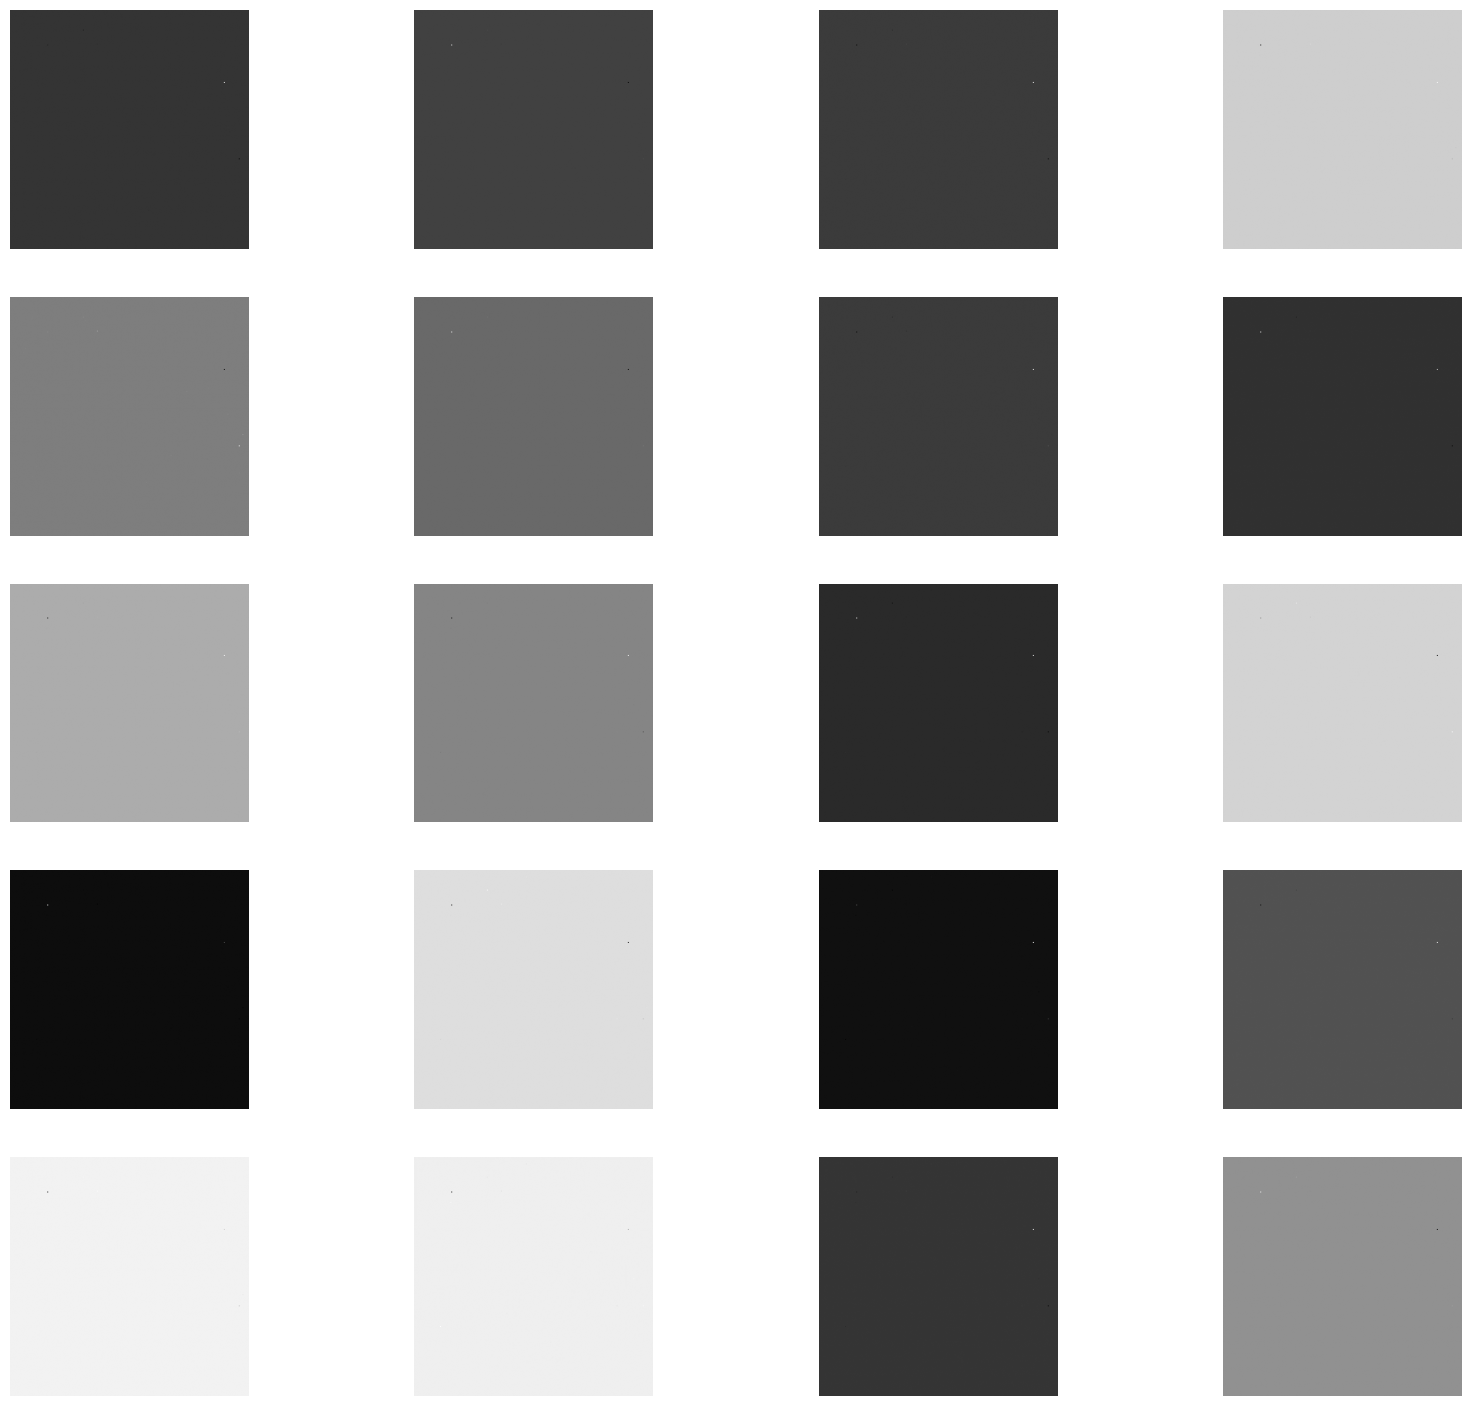

(18, torch.Size([1, 20, 256, 256]), 2)

In [17]:
# Plot the different invariant channels comming from flexi layer
results = flexi_layer(x)
fig, axs = plt.subplots(5, 4, figsize=(20, 18))
for i in range(5):
    for j in range(4):
        if i * 4 + j < results.shape[1]:
            axs[i, j].imshow(results[0, i * 4 + j].detach().cpu(), cmap='gray')
        axs[i, j].axis('off') 
plt.show()
flexi_layer.invariant_cnt, results.shape, flexi_layer._symmetric_cnt

In [18]:
from hippy2d.flexibleconv2d import FlexInv2D
x_rgb = rearrange(test_rgb_img, 'c h w -> 1 c h w')
x_rgb = torch.cat([x_rgb, x_rgb], dim=0)
rot_x_rgb = torch.rot90(x_rgb, 1, [-2, -1])

print(f"Input shape {x_rgb.shape}")
flexi_rgb = FlexInv2D(
    in_channels=3,
    out_channels=20,
    input_shape=256,
    filter_size=FILTER_SIZE,
    max_order=MAX_ORDER
)
flexi_rgb.eval()
torch.testing.assert_close(flexi_rgb(x_rgb), 
                           torch.rot90(flexi_rgb(rot_x_rgb), k=-1, dims=[-2, -1]))
torch.max(torch.abs(flexi_rgb(x_rgb) - torch.rot90(flexi_rgb(rot_x_rgb), k=-1, dims=[-2, -1])))

Input shape torch.Size([2, 3, 256, 256])


tensor(9.5308e-09, grad_fn=<MaxBackward1>)

In [19]:
from hippy2d.utils import tukey_2d
from hippy2d.flexibleconv2d import FlexBaseBlock

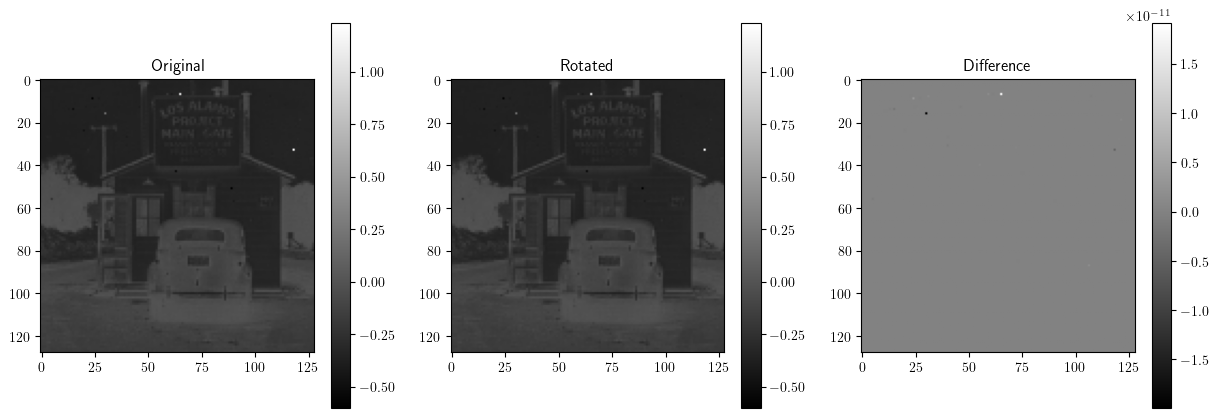

In [20]:
x_rgb = rearrange(test_rgb_img, 'c h w -> 1 c h w')
rot_x_rgb = torch.rot90(x_rgb, 1, [2, 3])

test_block = FlexBaseBlock(in_channels=3, out_channels=1, input_size=256)
test_block.eval()
torch.testing.assert_close(test_block(x_rgb), 
                           torch.rot90(test_block(rot_x_rgb), k=-1, dims=[-2, -1]))

output_1 = test_block(x_rgb).detach().numpy()[0, 0]
output_2 = torch.rot90(test_block(rot_x_rgb), k=-1, dims=[-2, -1]).detach().numpy()[0, 0]
# Plot 
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(output_1, cmap='gray')
plt.title("Original")
plt.colorbar()
plt.subplot(1, 3, 2)
plt.imshow(output_2, cmap='gray')
plt.title("Rotated")
plt.colorbar()
plt.subplot(1, 3, 3)
plt.imshow(output_1 - output_2, cmap='gray')
plt.title("Difference")
plt.colorbar()

In [21]:
flex_net = torch.nn.Sequential(
    FlexBaseBlock(in_channels=3,  out_channels=20, input_size=256, channels_masking="none", subsampling=False),
    FlexBaseBlock(in_channels=20, out_channels=20, input_size=256, channels_masking="none", subsampling=False),
    FlexBaseBlock(in_channels=20, out_channels=20, input_size=256, channels_masking="none", subsampling=True),
    #FlexBaseBlock(in_channels=20, out_channels=20, input_size=128, channels_masking="tukey", subsampling=False),
    #FlexBaseBlock(in_channels=20, out_channels=20, input_size=128, channels_masking="tukey", subsampling=False),
    #FlexBaseBlock(in_channels=20, out_channels=20, input_size=128, channels_masking="tukey", subsampling=True),
    #FlexBaseBlock(in_channels=20, out_channels=20, input_size=64, channels_masking="tukey", subsampling=False),
)
flex_net.eval()
output1 = flex_net(x_rgb)
output2 = torch.rot90(
    flex_net(rot_x_rgb),
    k=-1,
    dims=[-2, -1]
)
torch.testing.assert_close(output1, output2)


AssertionError: Tensor-likes are not close!

Mismatched elements: 34 / 327680 (0.0%)
Greatest absolute difference: 2.456755325397353e-06 at index (0, 19, 12, 53) (up to 1e-07 allowed)
Greatest relative difference: 8.8887171671092e-05 at index (0, 14, 56, 86) (up to 1e-07 allowed)

NameError: name 'complex_to_rgb' is not defined

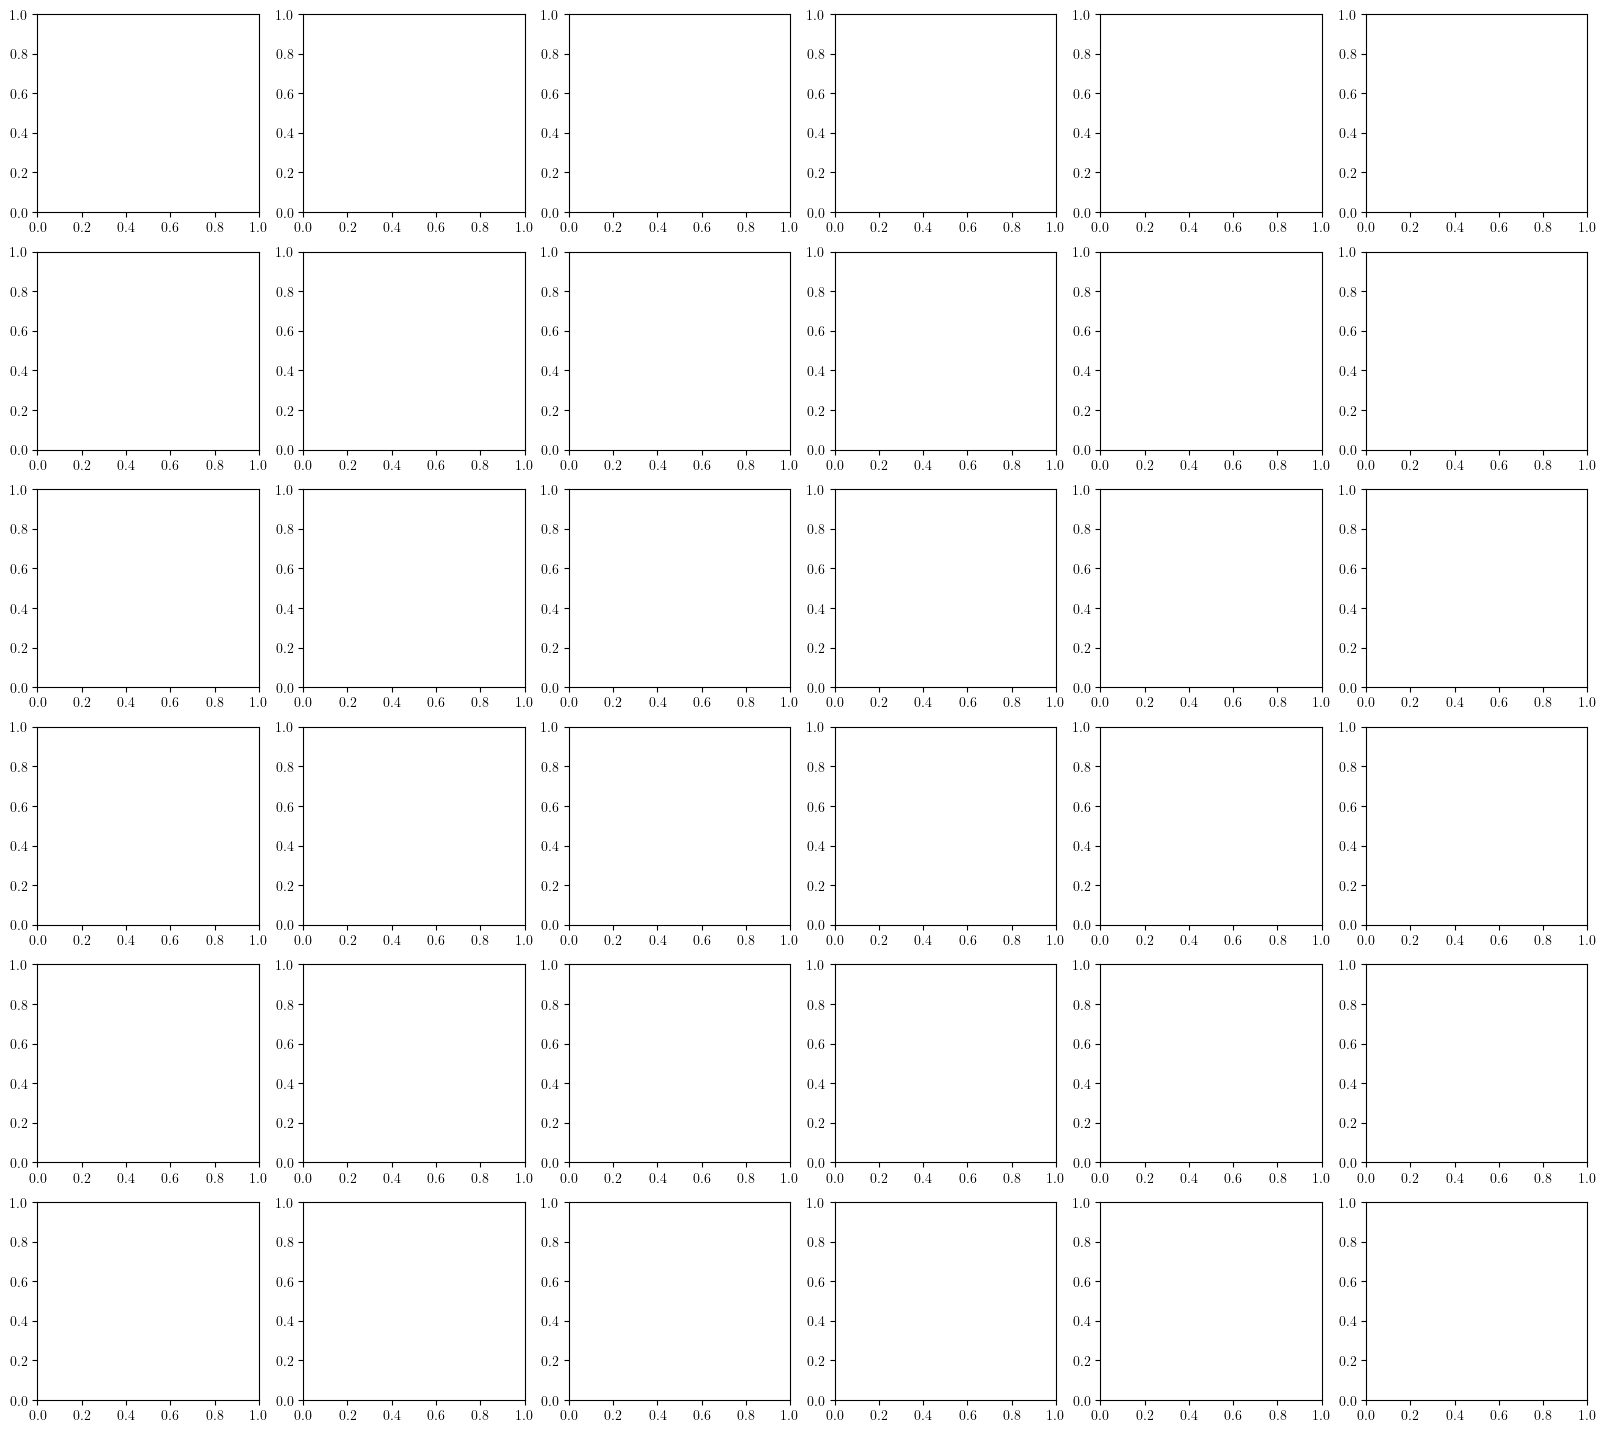

In [ ]:
# Observe the values and their differences

inv = get_inv(c_nonsymmetric_moments)
rot_inv = get_inv(rot_nonsymmetric_moments)

# plot all the channels
fig, axs = plt.subplots(inv.shape[1], inv.shape[2], figsize=(20, 18))
for i in range(inv.shape[1]):
    for j in range(inv.shape[2]):
        axs[i, j].imshow(complex_to_rgb(inv[0, i, j]), cmap='gray')
        axs[i, j].axis('off')
        _pq = non_symmetric_polynomials[i]
        _qp = non_symmetric_polynomials[j]
        axs[i, j].set_title(f"c{_pq}^{coef_a[i,j]} * c{_qp}^{coef_b[i,j]}")

Text(0.5, 0.98, 'Homogenous moments - Magnitude')

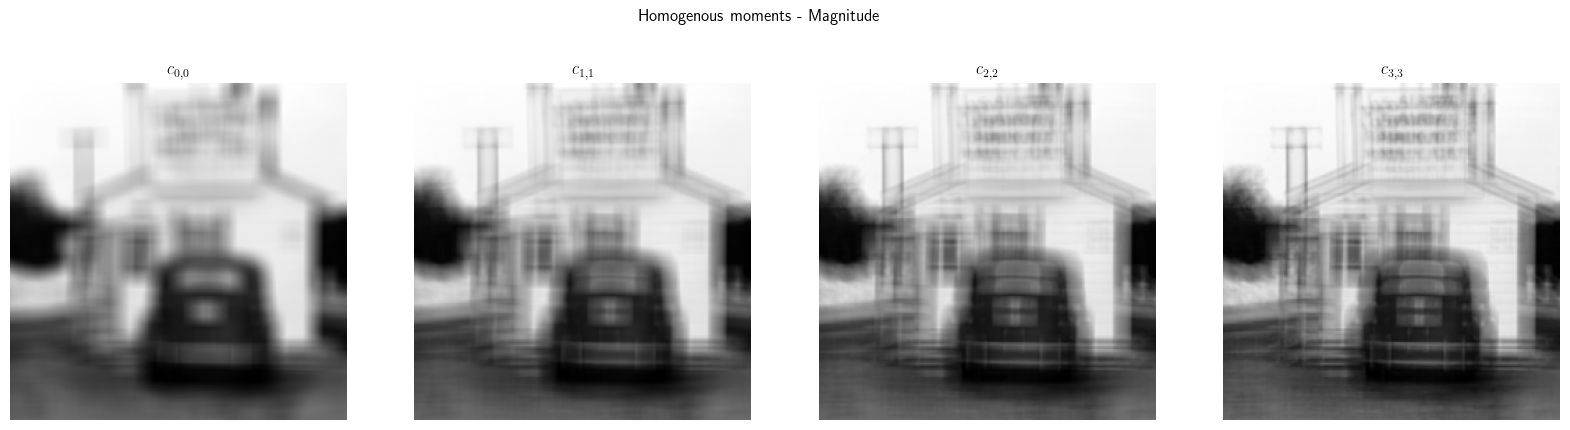

In [ ]:
# plot all the symmetric moments
fig, axs = plt.subplots(1, c_symmetric_moments.shape[1], figsize=(20, 5))
for i in range(c_symmetric_moments.shape[1]):
    axs[i].imshow(c_symmetric_moments[0, i].abs(), cmap='gray')
    axs[i].axis('off')
    _pq = symmetric_polynomials[i]
    axs[i].set_title(f"$c_{{{_pq[0]}, {_pq[1]}}}$")
fig.suptitle("Homogenous moments - Magnitude")

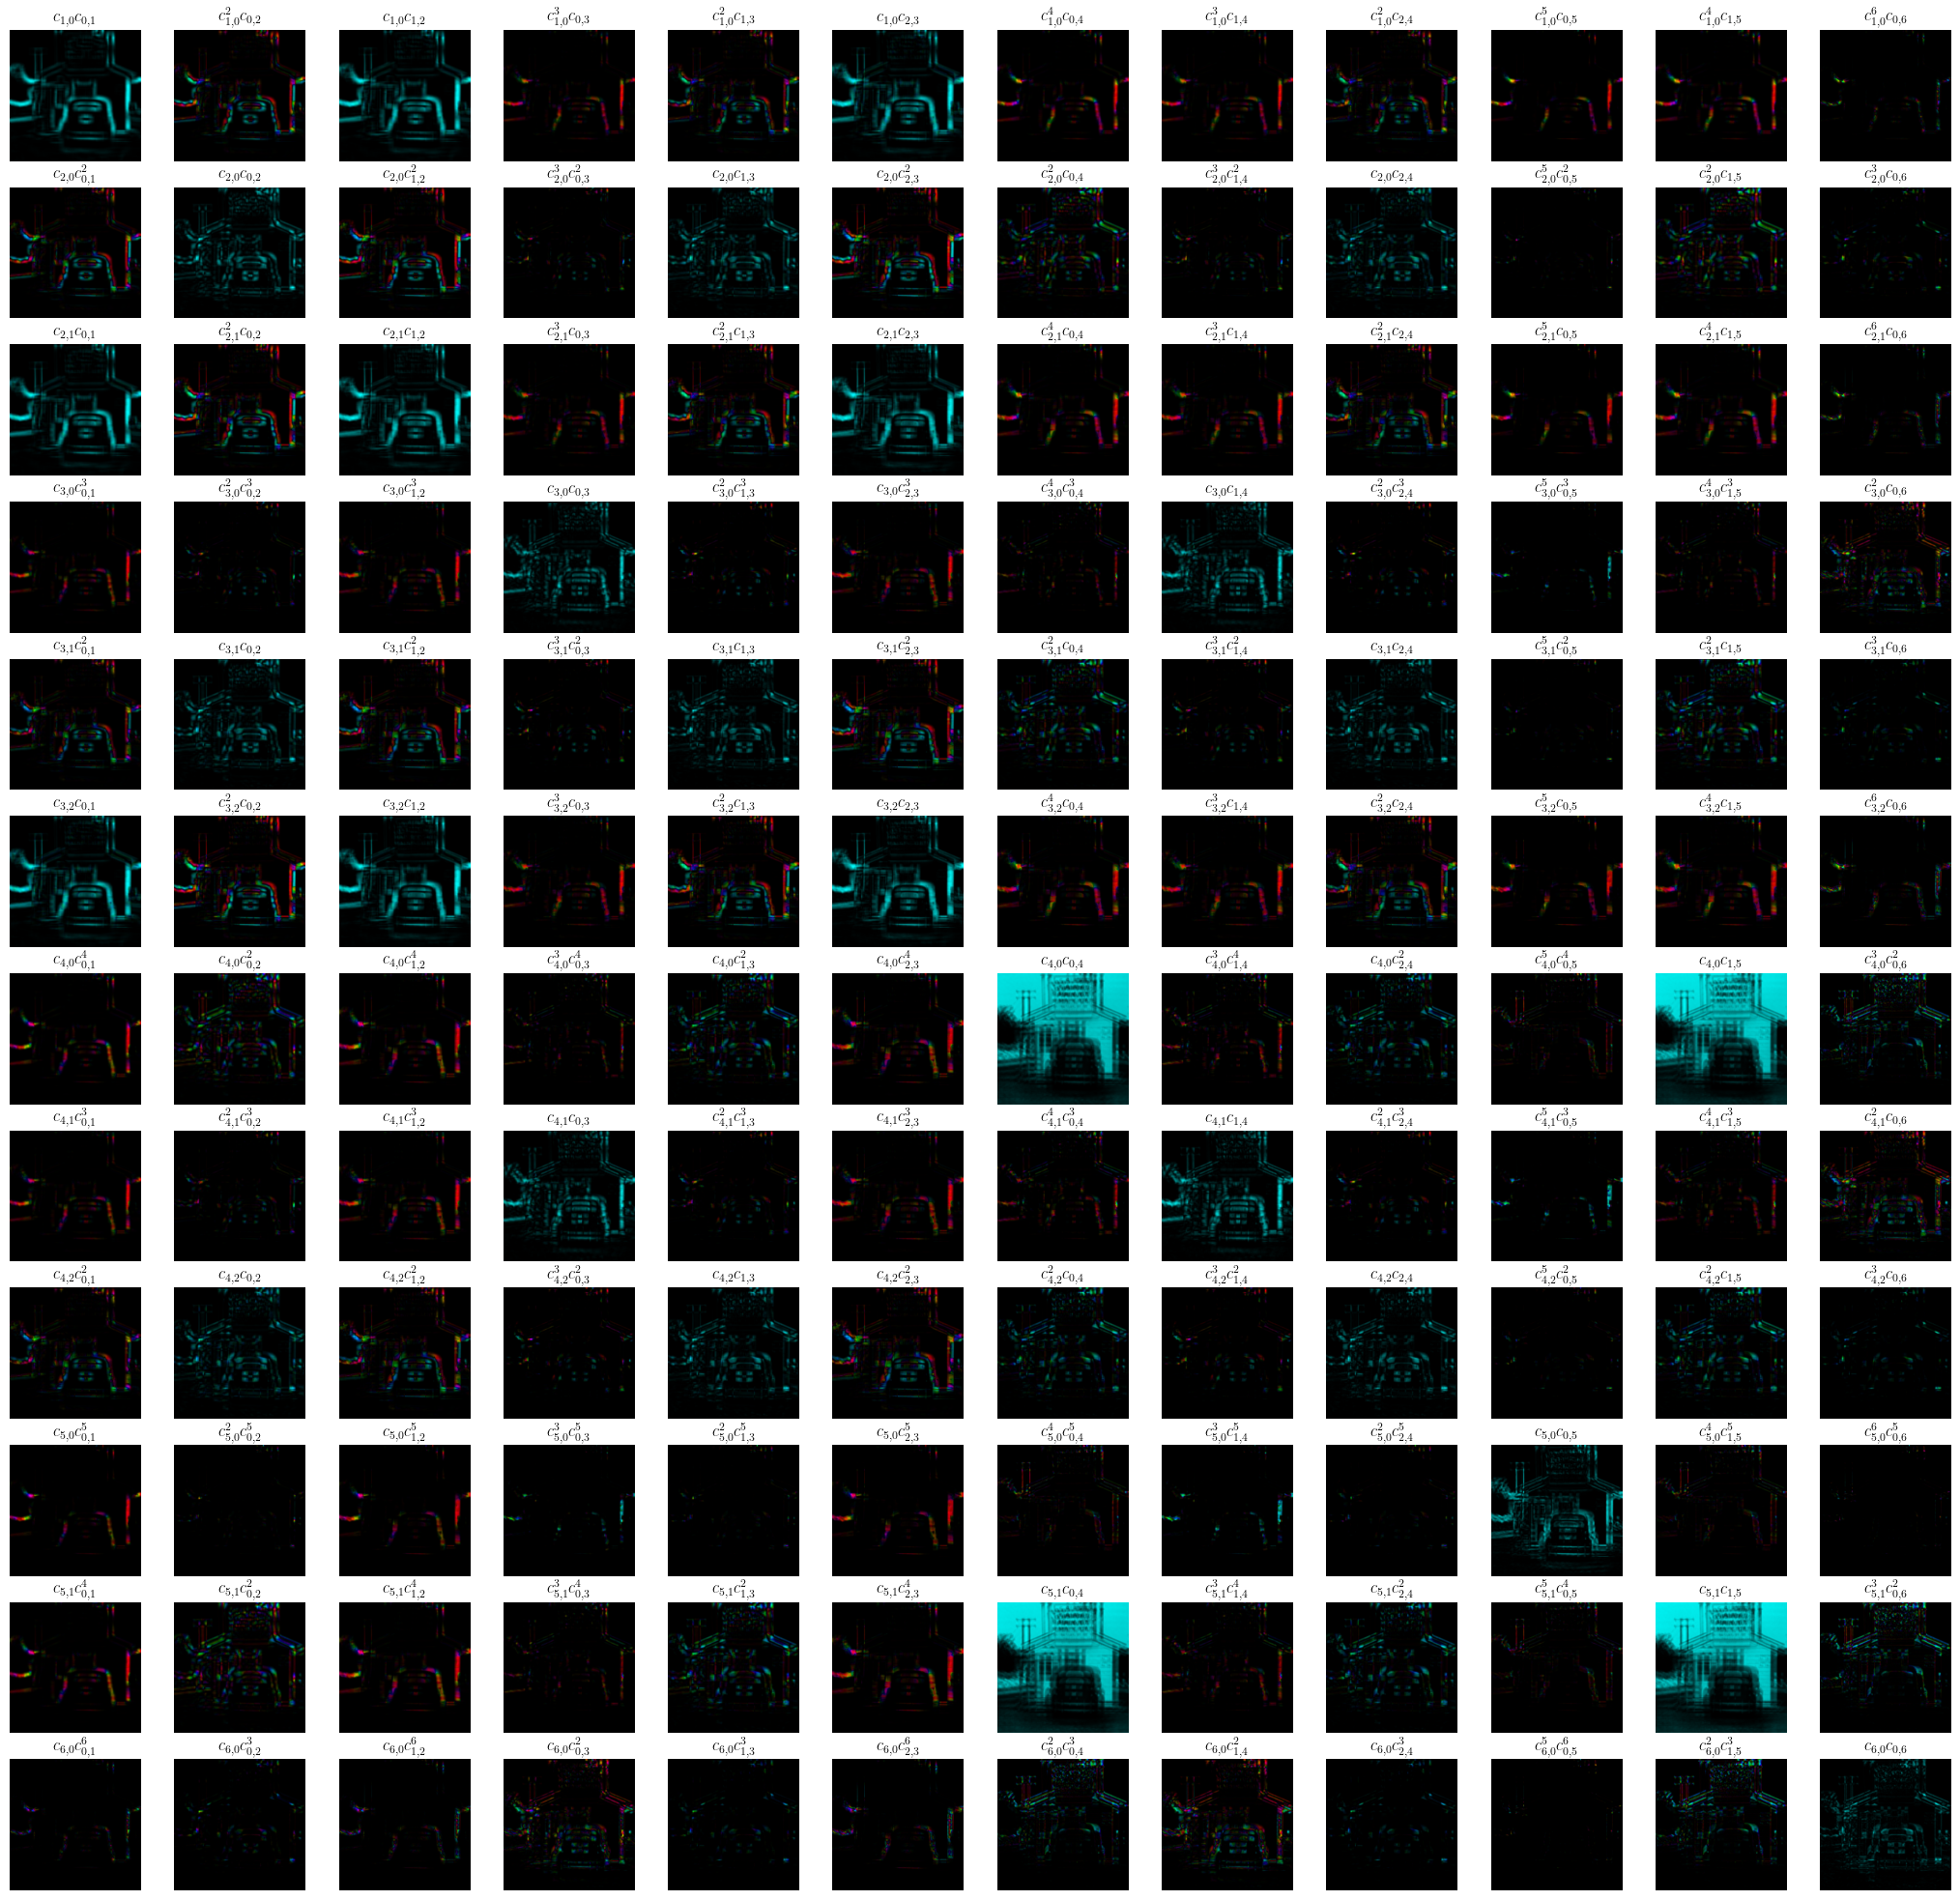

In [ ]:
import colorsys
c_inv = get_inv_c(c_nonsymmetric_moments, neg_c_nonsymmetric_moments)
rot_inv = get_inv_c(rot_nonsymmetric_moments, neg_rot_nonsymmetric_moments)

def complex_to_rgb(Z):
    mag = np.abs(Z)
    phase = np.angle(Z)
    norm_mag = mag / mag.max()
    
    hsv = np.zeros(Z.shape + (3,))
    hsv[..., 0] = (phase + np.pi) / (2*np.pi)   # hue
    hsv[..., 1] = 1.0                           # saturation
    hsv[..., 2] = norm_mag                      # value
    
    rgb = np.zeros_like(hsv)
    for i in range(Z.shape[0]):
        for j in range(Z.shape[1]):
            rgb[i,j] = colorsys.hsv_to_rgb(*hsv[i,j])
    return rgb



# plot all the channels
fig, axs = plt.subplots(inv.shape[1], inv.shape[2], figsize=(26, 25))
for i in range(inv.shape[1]):
    for j in range(inv.shape[2]):
        axs[i, j].imshow(complex_to_rgb(c_inv[0, i, j]), cmap='hsv')
        axs[i, j].axis('off')
        _pq = non_symmetric_polynomials[i]
        _qp = (non_symmetric_polynomials[j][1], non_symmetric_polynomials[j][0])
        if coef_a[i,j] == 1: 
            a = f"c_{{{_pq[0]},{_pq[1]}}}"
        else: 
            a = f"c_{{{_pq[0]},{_pq[1]}}}^{coef_a[i,j]}"
        if coef_c[i,j] == 1: 
            c = f"c_{{{_qp[0]},{_qp[1]}}}"
        else: 
            c = f"c_{{{_qp[0]},{_qp[1]}}}^{coef_c[i,j]}"
        axs[i, j].set_title(f"${a} {c}$")
#fig.suptitle("Flexible Set - Heterogeneous moments - Magnitude = Intensity, Color = Phase")


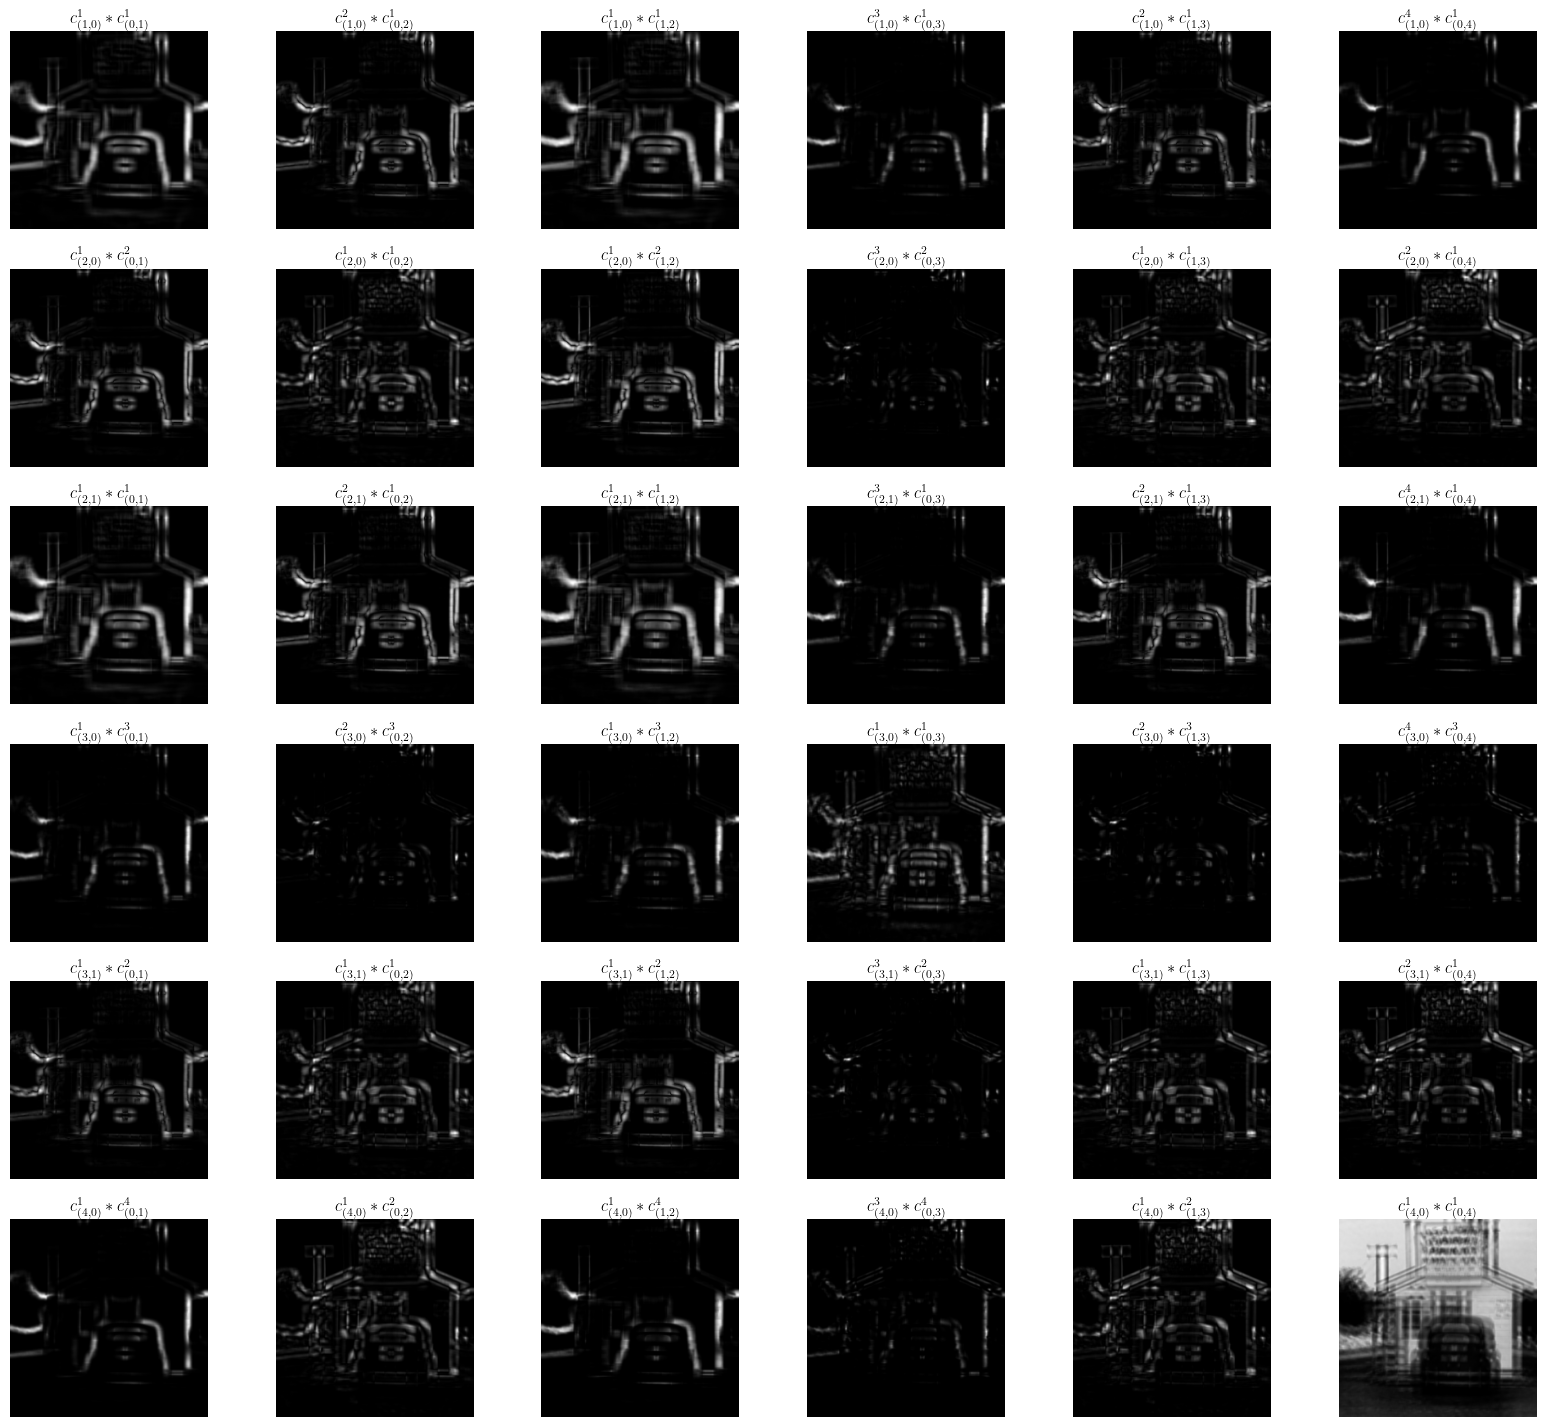

In [ ]:
c_inv = get_inv_c(c_nonsymmetric_moments, neg_c_nonsymmetric_moments)
rot_inv = get_inv_c(rot_nonsymmetric_moments, neg_rot_nonsymmetric_moments)

# plot all the channels
fig, axs = plt.subplots(inv.shape[1], inv.shape[2], figsize=(20, 18))
for i in range(inv.shape[1]):
    for j in range(inv.shape[2]):
        axs[i, j].imshow(c_inv[0, i, j].abs(), cmap='gray')
        axs[i, j].axis('off')
        _pq = non_symmetric_polynomials[i]
        _qp = (non_symmetric_polynomials[j][1], non_symmetric_polynomials[j][0])
        axs[i, j].set_title(f"$c_{{{_pq}}}^{coef_a[i,j]} * c_{{{_qp}}}^{{{coef_c[i,j]}}}$")

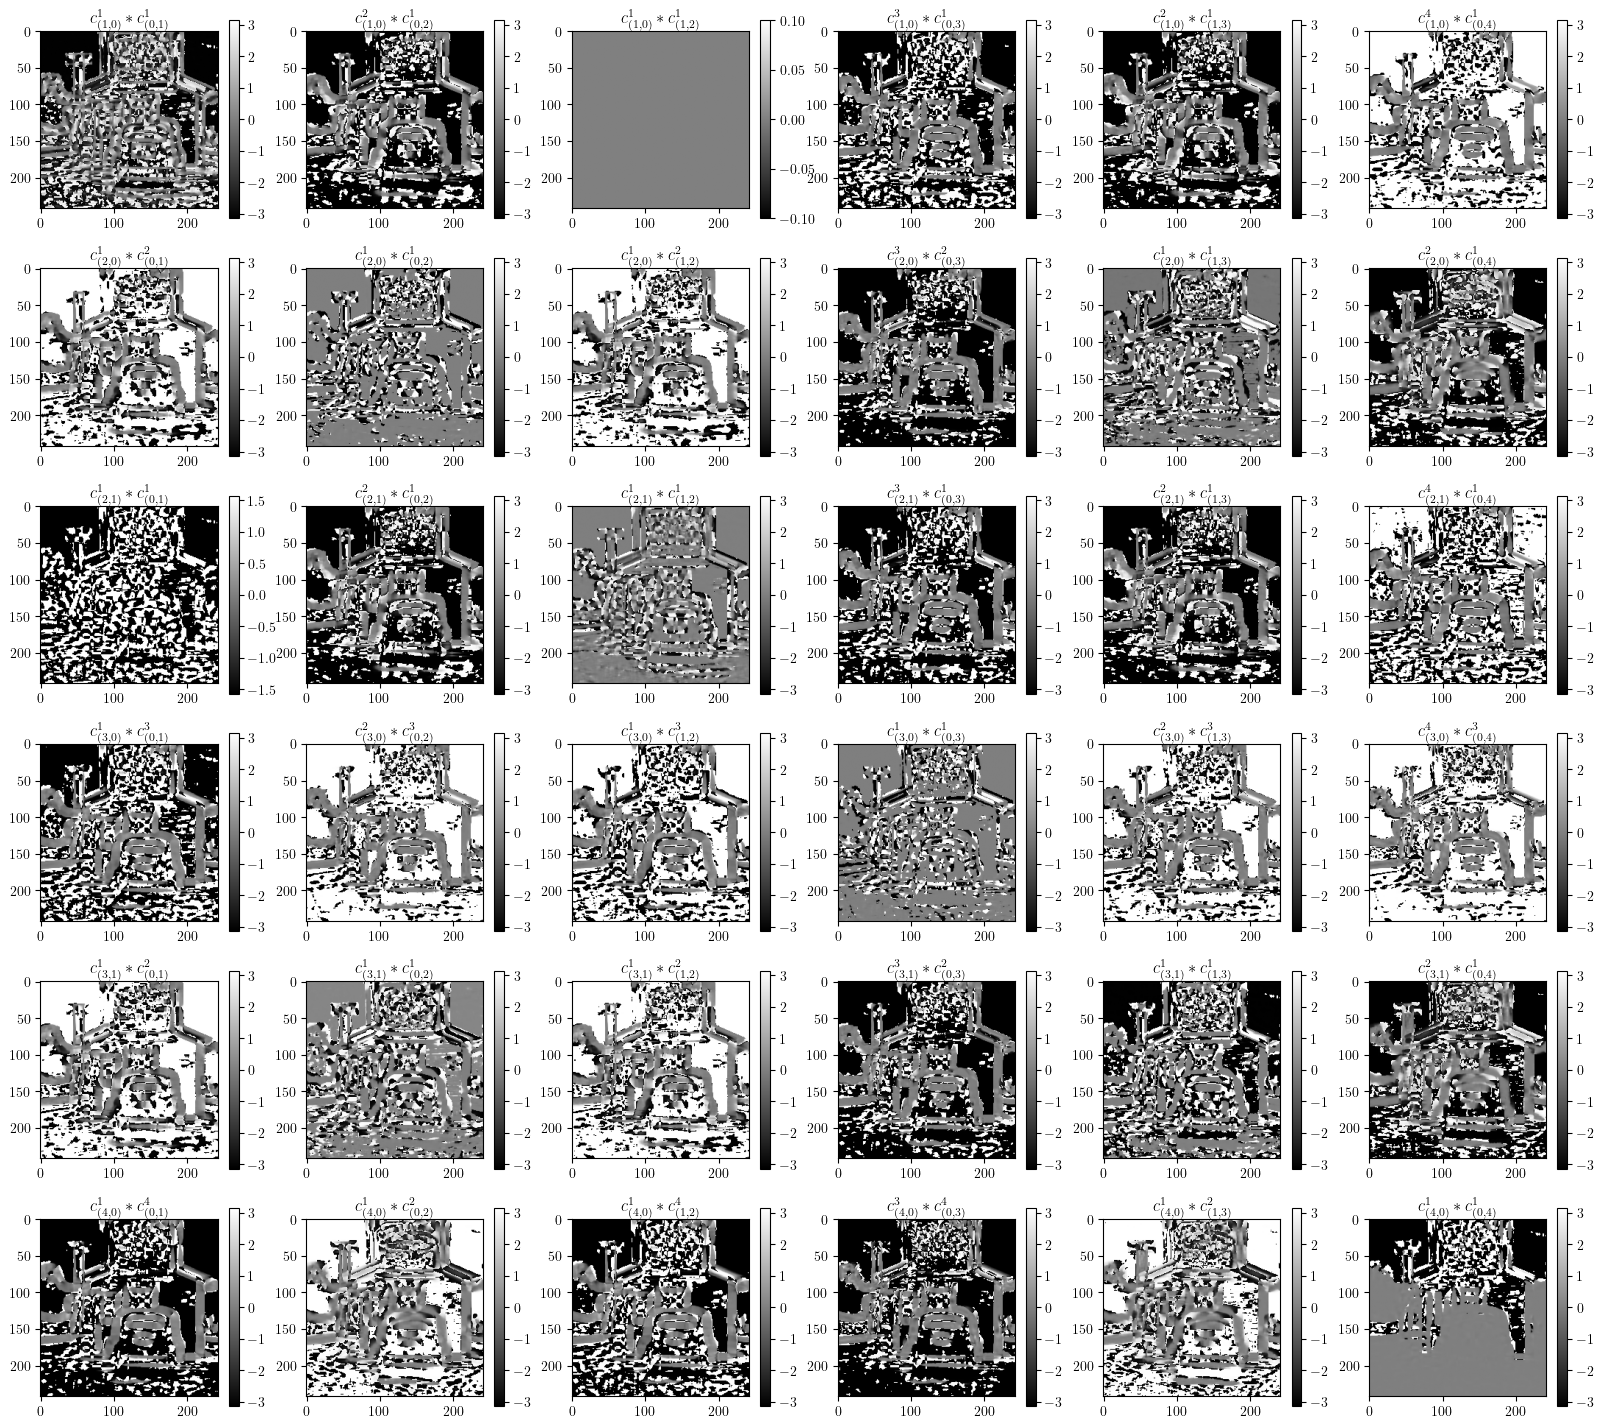

In [ ]:
a,b,_,_ = c_inv[0].shape
flat = rearrange(c_inv[0], "a b h w -> (a b) h w")
flat = (flat - (flat.mean(dim=-1).mean(dim=-1))[..., None, None])/ (flat.std(dim=-1).std(dim=-1))[..., None, None]
imgs = rearrange((flat[:, None] - flat), "g (a b) h w -> g a b h w", a=a, b=b).angle()
diff_0 = imgs[2]
# Plot 
fig, axs = plt.subplots(diff_0.shape[0], diff_0.shape[1], figsize=(20, 18))
for i in range(diff_0.shape[0]):
    for j in range(diff_0.shape[1]):
        axs[i, j].imshow(diff_0[i, j].detach().cpu(), cmap='hsv')
        _pq = non_symmetric_polynomials[i]
        _qp = (non_symmetric_polynomials[j][1], non_symmetric_polynomials[j][0])
        axs[i, j].set_title(f"$c_{{{_pq}}}^{coef_a[i,j]} * c_{{{_qp}}}^{coef_c[i,j]}$")
        fig.colorbar(axs[i, j].imshow(diff_0[i, j].detach().cpu(), cmap='gray'), ax=axs[i, j])


In [29]:
!ls 

01_complex_invariant_layer.ipynb 07_filter_size.ipynb
02_blind_spots_harmonics.ipynb   08_metrics.ipynb
03_datasets.ipynb                09_radial_part.ipynb
04_orientation_encoding.ipynb    10_flexible.ipynb
05_katylin_ds.ipynb              lightning_logs
06_timm_tiny_models.ipynb
